<a href="https://colab.research.google.com/github/RafaelCaballero/BME/blob/main/modelos_imagenes_huggingface.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table>
<tr>
<td><img src="https://www.institutobme.es/dam/layout/bme-logo.svg" width="150"></td>
<td><table><tr><td><h1>Modelos IA para imágenes</h1></td></tr>
           <tr><td><h3>Rafael Caballero Roldán</h3></td></tr></table></td>

</tr>
</table>

Este cuaderno muestra varias capacidades de visión artificial mediante modelos descargables de Hugging Face:

1. clasificación de imágenes;
2. clasificación de categorías definidas por el usuario (*zero-shot*);
3. detección de objetos y cajas delimitadoras;
4. generación automática de una descripción de la imagen.

La primera ejecución será más lenta porque descarga los modelos. Después quedan almacenados en la caché local.


In [22]:
import os
import importlib

EN_COLAB = importlib.util.find_spec("google.colab") is not None

def colab():
  if EN_COLAB:
    os.environ["HF_HUB_DISABLE_XET"] = "1"
    os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "120"
    os.environ["HF_HUB_ETAG_TIMEOUT"] = "30"

## 1. Instalación

Se fija `transformers` a la rama 4.x para mantener compatibles las interfaces utilizadas.


In [23]:
%pip install "transformers>=4.46,<5" requests sentencepiece timm

## 2. Preparación y dispositivo


In [24]:
import torch
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd

DEVICE = 0 if torch.cuda.is_available() else -1
TORCH_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Dispositivo:", TORCH_DEVICE)
print("Versión de PyTorch:", torch.__version__)

Dispositivo: cpu
Versión de PyTorch: 2.11.0+cpu


## 3. Obtener una imagen de demostración

Puede sustituirse la URL por una ruta local:

```python
imagen = Image.open("mi_imagen.jpg").convert("RGB")
```


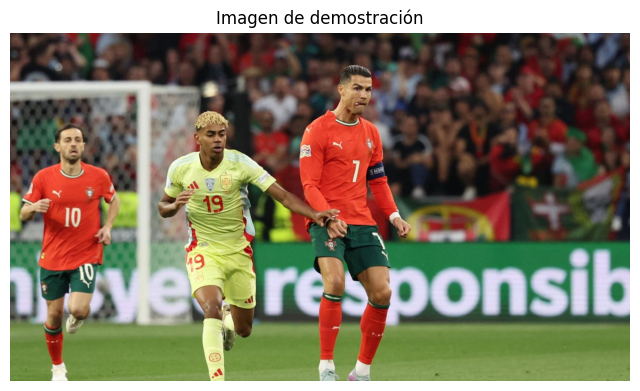

In [25]:
URL_IMAGEN = "https://images.ecestaticos.com/WroTgzk9jGdrlCxM-tGrVPDQYC0=/0x0:2272x1277/1338x752/filters:fill(white):format(jpg)/f.elconfidencial.com%2Foriginal%2F50e%2F174%2Ff04%2F50e174f046b5111a097b699d91b7012d.jpg"
#URL_IMAGEN = "https://www.institutobme.es/dam/images/bme-entrance-full.six-image.standard.2560.jpg"
#URL_IMAGEN = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/coco_sample.png"

respuesta = requests.get(URL_IMAGEN, timeout=30)
respuesta.raise_for_status()
imagen = Image.open(BytesIO(respuesta.content)).convert("RGB")

plt.figure(figsize=(8, 6))
plt.imshow(imagen)
plt.axis("off")
plt.title("Imagen de demostración")
plt.show()

## 4. Clasificación de imágenes

Un clasificador asigna la imagen completa a una de las clases aprendidas durante su entrenamiento.

Usaremos un Vision Transformer entrenado con las clases de ImageNet.


In [26]:
### ESTO SOLO ES NECESARIO EN GOOGLE COLAB
colab()


In [ ]:
from transformers import pipeline

clasificador_imagen = pipeline(
    task="image-classification",
    model="google/vit-base-patch16-224",
    device=DEVICE
)

predicciones = clasificador_imagen(imagen, top_k=5)
pd.DataFrame(predicciones)

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cpu


### Interpretación

El modelo solo puede elegir entre las clases conocidas durante su entrenamiento. Si la imagen contiene varios objetos, la etiqueta devuelta no tiene por qué describirlos todos.


## 5. Clasificación *zero-shot* con CLIP

CLIP permite comparar una imagen con etiquetas escritas por nosotros. No es necesario reentrenar el modelo para cada nuevo conjunto de categorías.

Los nombres de las categorías suelen funcionar mejor como descripciones breves.


In [ ]:
clasificador_zero_shot = pipeline(
    task="zero-shot-image-classification",
    model="openai/clip-vit-base-patch32",
    device=DEVICE
)

etiquetas = [
    "una fotografía de perros",
    "una fotografía de gatos",
    "una fotografía de personas",
    "una fotografía de un paisaje",
    "una fotografía de comida",
    "una fotografía de un edificio"
]

resultado_clip = clasificador_zero_shot(
    imagen,
    candidate_labels=etiquetas
)

pd.DataFrame(resultado_clip)

### Experimento

Prueba etiquetas muy generales y luego etiquetas específicas. Observa que las puntuaciones dependen del conjunto de opciones que se proporciona.


## 6. Detección de objetos

La detección localiza varios objetos y devuelve:

- una etiqueta;
- una puntuación;
- una caja delimitadora.

Usaremos DETR, un modelo basado en Transformers para detección.


In [ ]:
# SOLO EN COLAB
colab()

In [ ]:
detector = pipeline(
    task="object-detection",
    model="facebook/detr-resnet-50",
    device=DEVICE
)

detecciones = detector(imagen, threshold=0.7)
detecciones[:5]

In [ ]:
from PIL import ImageDraw

imagen_cajas = imagen.copy()
draw = ImageDraw.Draw(imagen_cajas)

for d in detecciones:
    caja = d["box"]
    xy = [caja["xmin"], caja["ymin"], caja["xmax"], caja["ymax"]]
    draw.rectangle(xy, width=4)
    draw.text(
        (caja["xmin"] + 4, caja["ymin"] + 4),
        f'{d["label"]}: {d["score"]:.2f}'
    )

plt.figure(figsize=(10, 7))
plt.imshow(imagen_cajas)
plt.axis("off")
plt.title("Objetos detectados")
plt.show()

## 7. Generar una descripción de la imagen

BLIP combina visión y lenguaje para generar una frase que describe la imagen.

El modelo de este ejemplo genera normalmente la descripción en inglés. Puede traducirse posteriormente con otro modelo, pero conviene analizar primero si la descripción visual es correcta.


In [ ]:
# solo en colab
colab()

In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration

MODELO_BLIP = "Salesforce/blip-image-captioning-base"

procesador_blip = BlipProcessor.from_pretrained(MODELO_BLIP)
modelo_blip = BlipForConditionalGeneration.from_pretrained(MODELO_BLIP).to(TORCH_DEVICE)

entradas = procesador_blip(images=imagen, return_tensors="pt").to(TORCH_DEVICE)

with torch.no_grad():
    salida = modelo_blip.generate(
        **entradas,
        max_new_tokens=40,
        num_beams=4
    )

descripcion = procesador_blip.decode(salida[0], skip_special_tokens=True)
print("Descripción generada:", descripcion)